<a href="https://colab.research.google.com/github/harrisariefkamis/Data-Analyst-Project-Business-Decision-Research/blob/main/Project_Bussines_Decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Bussines Decision

IMPORT DATA

In [1]:
import pandas as pd
df = pd.read_csv('https://storage.googleapis.com/dqlab-dataset/data_retail.csv', sep=';')
print('Lima data teratas:')
print(df.head())
print('\nInfo dataset:')
print(df.info())

Lima data teratas:
   no  Row_Num  Customer_ID Product  First_Transaction  Last_Transaction  \
0   1        1        29531   Jaket      1466304274396     1538718482608   
1   2        2        29531  Sepatu      1406077331494     1545735761270   
2   3        3       141526     Tas      1493349147000     1548322802000   
3   4        4       141526   Jaket      1493362372547     1547643603911   
4   5        5        37545  Sepatu      1429178498531     1542891221530   

   Average_Transaction_Amount  Count_Transaction  
0                     1467681                 22  
1                     1269337                 41  
2                      310915                 30  
3                      722632                 27  
4                     1775036                 25  

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      ----

DATA CLEANSING

In [2]:
import pandas as pd
df = pd.read_csv('https://storage.googleapis.com/dqlab-dataset/data_retail.csv', sep=';')
# Kolom First_Transaction
df['First_Transaction'] = pd.to_datetime(df['First_Transaction']/1000, unit='s', origin='1970-01-01')
# Kolom Last_Transaction
df['Last_Transaction'] = pd.to_datetime(df['Last_Transaction']/1000, unit='s', origin='1970-01-01')
print('Lima data teratas:')
print(df.head())
print('\nInfo dataset:')
print(df.info())

Lima data teratas:
   no  Row_Num  Customer_ID Product             First_Transaction  \
0   1        1        29531   Jaket 2016-06-19 02:44:34.395999908   
1   2        2        29531  Sepatu 2014-07-23 01:02:11.493999958   
2   3        3       141526     Tas 2017-04-28 03:12:27.000000000   
3   4        4       141526   Jaket 2017-04-28 06:52:52.546999931   
4   5        5        37545  Sepatu 2015-04-16 10:01:38.530999899   

               Last_Transaction  Average_Transaction_Amount  Count_Transaction  
0 2018-10-05 05:48:02.608000040                     1467681                 22  
1 2018-12-25 11:02:41.269999981                     1269337                 41  
2 2019-01-24 09:40:02.000000000                      310915                 30  
3 2019-01-16 13:00:03.911000013                      722632                 27  
4 2018-11-22 12:53:41.529999970                     1775036                 25  

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries,

CHURN DATA CUSTOMER

In [3]:
import pandas as pd
df = pd.read_csv('https://storage.googleapis.com/dqlab-dataset/data_retail.csv', sep=';')
df['First_Transaction'] = pd.to_datetime(df['First_Transaction']/1000, unit='s', origin='1970-01-01')
df['Last_Transaction'] = pd.to_datetime(df['Last_Transaction']/1000, unit='s', origin='1970-01-01')
# Pengecekan transaksaksi terakhir dalam dataset
latest_transaction_date = df['Last_Transaction'].max()
print('Transaksi terakhir dalam dataset: {latest_transaction_date}')
# Klasifikasikan customer yang berstatus churn atau tidak dengan boolean
# Asumsi churn jika Last_Transaction lebih dari 6 bulan sebelum transaksi terakhir di dataset
churn_threshold = latest_transaction_date - pd.Timedelta(days=180)
df['is_churn'] = (df['Last_Transaction'] < churn_threshold)
print('Lima data teratas:')
print(df.head())
print('\nInfo dataset:')
print(df.info())
# Hitung jumlah pelanggan yang churn dan tidak churn
churn_counts = df['is_churn'].value_counts().reset_index()
churn_counts.columns = ['is_churn', 'count']
print('Jumlah pelanggan churn dan tidak churn:')
print(churn_counts)
#Menghapus kolom
del df['no']
del df['Row_Num']
print(df.head())
df['Year_First_Transaction'] = df['First_Transaction'].dt.year
# Count the number of customers acquired each year
customer_acquisition_by_year = df.groupby('Year_First_Transaction').agg(Count_Customer = ('Customer_ID','count')).reset_index()
print('Jumlah customer akuisisi per tahun:')
print(customer_acquisition_by_year)

Transaksi terakhir dalam dataset: {latest_transaction_date}
Lima data teratas:
   no  Row_Num  Customer_ID Product             First_Transaction  \
0   1        1        29531   Jaket 2016-06-19 02:44:34.395999908   
1   2        2        29531  Sepatu 2014-07-23 01:02:11.493999958   
2   3        3       141526     Tas 2017-04-28 03:12:27.000000000   
3   4        4       141526   Jaket 2017-04-28 06:52:52.546999931   
4   5        5        37545  Sepatu 2015-04-16 10:01:38.530999899   

               Last_Transaction  Average_Transaction_Amount  \
0 2018-10-05 05:48:02.608000040                     1467681   
1 2018-12-25 11:02:41.269999981                     1269337   
2 2019-01-24 09:40:02.000000000                      310915   
3 2019-01-16 13:00:03.911000013                      722632   
4 2018-11-22 12:53:41.529999970                     1775036   

   Count_Transaction  is_churn  
0                 22     False  
1                 41     False  
2                 30     Fal

## Visualisasi Customer Akusisi per tahun

/tmp/ipykernel_7607/2128281353.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year_First_Transaction', y='Count_Customer', data=customer_acquisition_by_year, palette='viridis')


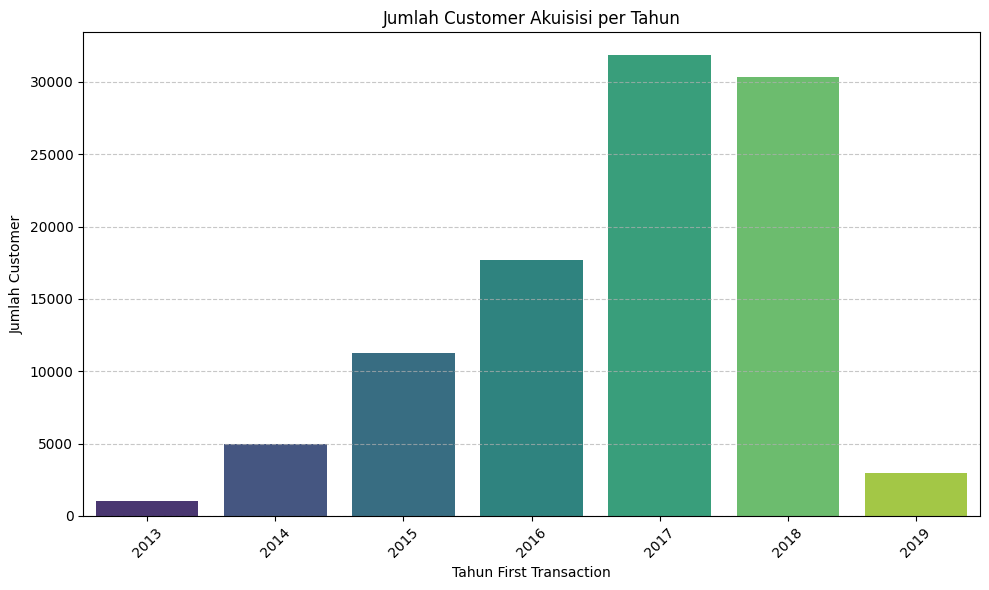

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x='Year_First_Transaction', y='Count_Customer', data=customer_acquisition_by_year, palette='viridis')
plt.title('Jumlah Customer Akuisisi per Tahun')
plt.xlabel('Tahun First Transaction')
plt.ylabel('Jumlah Customer')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Year_First_Transaction', y='Count_Customer', data=df_year, hue='Year_First_Transaction', palette='viridis', legend=False)
plt.title('Jumlah Akuisisi Pelanggan per Tahun (Berdasarkan Transaksi Pertama)')
plt.xlabel('Tahun Transaksi Pertama')
plt.ylabel('Jumlah Pelanggan Baru')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

NameError: name 'df_year' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='Year_First_Transaction', y='Count_Customer',data=df_year, hue='Year_First_Transaction', palette='viridis', legend=False)
plt.title('Jumlah Pelanggan Baru per Tahun') # Changed title to reflect 'Count_Customer'
plt.xlabel('Tahun Transaksi Pertama')
plt.ylabel('Jumlah Pelanggan Baru')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualisasi Rata-Rata Amount Transaksi per Tahun

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average transaction amount per year
avg_transaction_amount_per_year = df.groupby('Year_First_Transaction')['Average_Transaction_Amount'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Year_First_Transaction', y='Average_Transaction_Amount', data=avg_transaction_amount_per_year, palette='viridis', hue='Year_First_Transaction', legend=False)
plt.title('Rata-Rata Amount Transaksi per Tahun')
plt.xlabel('Tahun Transaksi Pertama')
plt.ylabel('Rata-Rata Amount Transaksi')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualisasi Proporsi Count Transaksi Customer Churn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (if not already loaded and processed in the current session)
df = pd.read_csv('https://storage.googleapis.com/dqlab-dataset/data_retail.csv', sep=';')

# Convert transaction dates to datetime objects
df['First_Transaction'] = pd.to_datetime(df['First_Transaction']/1000, unit='s', origin='1970-01-01')
df['Last_Transaction'] = pd.to_datetime(df['Last_Transaction']/1000, unit='s', origin='1970-01-01')

# Define churn based on the latest transaction date
latest_transaction_date = df['Last_Transaction'].max()
churn_threshold = latest_transaction_date - pd.Timedelta(days=180)
df['is_churn'] = (df['Last_Transaction'] < churn_threshold)

# Calculate the total transaction count for churned and non-churned customers
churn_transaction_counts = df.groupby('is_churn')['Count_Transaction'].sum().reset_index()

plt.figure(figsize=(8, 8))
plt.pie(churn_transaction_counts['Count_Transaction'],
        labels=churn_transaction_counts['is_churn'].map({True: 'Churned', False: 'Not Churned'}),
        autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'],
        startangle=90,
        explode=[0.05, 0]) # Explode the 'Churned' slice slightly
plt.title('Proporsi Total Count Transaksi berdasarkan Status Churn')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## Visualisasi Distribusi Kategori Count Transaksi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the total transaction count for each product category
product_transaction_counts = df.groupby('Product')['Count_Transaction'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Product', y='Count_Transaction', data=product_transaction_counts, palette='magma', hue='Product', legend=False)
plt.title('Distribusi Total Count Transaksi per Kategori Produk')
plt.xlabel('Kategori Produk')
plt.ylabel('Total Count Transaksi')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualisasi Kategori Rata-Rata Amount Transaksi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average transaction amount for each product category
product_avg_transaction_amount = df.groupby('Product')['Average_Transaction_Amount'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Product', y='Average_Transaction_Amount', data=product_avg_transaction_amount, palette='viridis', hue='Product', legend=False)
plt.title('Rata-Rata Amount Transaksi per Kategori Produk')
plt.xlabel('Kategori Produk')
plt.ylabel('Rata-Rata Amount Transaksi')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Feature dan Target

In [ ]:
# Kolom tahun transaksi terakhir
df['Year_Last_Transaction'] = df['Last_Transaction'].dt.year

# Tampilkan 5 baris teratas dengan kolom baru
print(df[['Last_Transaction', 'Year_Last_Transaction']].head())

In [ ]:
import pandas as pd

# Re-load data to ensure consistency (or ensure previous cells are run)
df = pd.read_csv('https://storage.googleapis.com/dqlab-dataset/data_retail.csv', sep=';')

# Convert transaction dates to datetime objects (from previous steps)
df['First_Transaction'] = pd.to_datetime(df['First_Transaction']/1000, unit='s', origin='1970-01-01')
df['Last_Transaction'] = pd.to_datetime(df['Last_Transaction']/1000, unit='s', origin='1970-01-01')

# Calculate is_churn (from previous steps)
latest_transaction_date = df['Last_Transaction'].max()
churn_threshold = latest_transaction_date - pd.Timedelta(days=180)
df['is_churn'] = (df['Last_Transaction'] < churn_threshold)

# Drop unnecessary columns (from previous steps)
del df['no']
del df['Row_Num']

# Extract year columns (from previous steps)
df['Year_First_Transaction'] = df['First_Transaction'].dt.year
df['Year_Last_Transaction'] = df['Last_Transaction'].dt.year

# Define feature columns (X)
# 'Average_Transaction_Amount' and 'Count_Transaction' are numerical features.
# 'Year_First_Transaction' and 'Year_Last_Transaction' are derived numerical features.
# 'Product' is a categorical feature that will need encoding.
X = df[['Average_Transaction_Amount', 'Count_Transaction', 'Year_First_Transaction', 'Year_Last_Transaction', 'Product']]

# Define target column (y)
y = df['is_churn']

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)
print('\nFeatures (X) head:')
print(X.head())
print('\nTarget (y) head:')
print(y.head())

## One-Hot Encoding for 'Product' and Data Splitting

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the 'Product' column
product_encoded = ohe.fit_transform(X[['Product']])

# Create a DataFrame with the encoded product features
product_df = pd.DataFrame(product_encoded, columns=ohe.get_feature_names_out(['Product']))

# Drop the original 'Product' column from X and concatenate the new encoded columns
X = pd.concat([X.drop(columns=['Product']), product_df], axis=1)

print('Shape of X after One-Hot Encoding:', X.shape)
print('\nFeatures (X) head after One-Hot Encoding:')
print(X.head())

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

print('\nX_train head:')
print(X_train.head())
print('\ny_train head:')
print(y_train.head())

## Fungsi Modular untuk Pelatihan Model

Untuk membuat kode lebih rapi dan reusable, kita akan mengemas proses pelatihan dan evaluasi model Random Forest ke dalam sebuah fungsi.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

def train_and_evaluate_random_forest(X_train, y_train, X_test, y_test, n_estimators=100, random_state=42):
    """
    Melatih model Random Forest Classifier dan mengevaluasinya.

    Args:
        X_train (pd.DataFrame): Data fitur untuk pelatihan.
        y_train (pd.Series): Target untuk pelatihan.
        X_test (pd.DataFrame): Data fitur untuk pengujian.
        y_test (pd.Series): Target untuk pengujian.
        n_estimators (int): Jumlah pohon dalam hutan acak.
        random_state (int): Seed untuk reproduksibilitas.

    Returns:
        tuple: (trained_model, y_pred, accuracy, precision, recall)
    """
    print(f"Memulai pelatihan model Random Forest dengan {n_estimators} estimator...")
    # Initialize the Random Forest Classifier model
    rf_model = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, class_weight='balanced')

    # Train the model using the training data
    rf_model.fit(X_train, y_train)
    print("Model Random Forest berhasil dilatih.")

    # Make predictions on the test set
    y_pred = rf_model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f'\nRandom Forest Accuracy: {accuracy:.4f}')
    print(f'Random Forest Precision: {precision:.4f}')
    print(f'Random Forest Recall: {recall:.4f}')

    # Generate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.title('Confusion Matrix (Random Forest)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return rf_model, y_pred, accuracy, precision, recall

## Fungsi Modular untuk Melatih dan Mengevaluasi Model

In [ ]:
# Panggil fungsi modular untuk melatih dan mengevaluasi model Random Forest
rf_model, y_pred_rf, accuracy_rf, precision_rf, recall_rf = train_and_evaluate_random_forest(X_train, y_train, X_test, y_test)

print("\nModel Random Forest (dilatih via fungsi) dan metrik evaluasi telah tersedia.")

## Model Training and Prediction

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

# Make predictions on the test set
y_pred = model.predict(X_test)

print("\nFirst 10 predictions on the test set:")
print(y_pred[:10])
print("\nFirst 10 actual values from the test set:")
print(y_test[:10].values)

## Model Evaluation: Confusion Matrix, Accuracy, Precision, and Recall

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Model Training and Evaluation with Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
# Using a small number of estimators for faster execution in Colab, consider increasing for production
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model using the training data
rf_model.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("\nFirst 10 predictions on the test set (Random Forest):")
print(y_pred_rf[:10])
print("\nFirst 10 actual values from the test set:")
print(y_test[:10].values)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print(f'Random Forest Accuracy: {accuracy_rf:.4f}')
print(f'Random Forest Precision: {precision_rf:.4f}')
print(f'Random Forest Recall: {recall_rf:.4f}')

# Generate Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Ringkasan Insight Bisnis dan Rekomendasi dari Model Random Forest

Setelah melakukan analisis data dan melatih dua model prediksi churn, yaitu Regresi Logistik dan Random Forest, kita mendapatkan beberapa insight kunci dan rekomendasi bisnis:

### 1. Perbaikan Model Prediksi Churn
*   **Regresi Logistik:** Model awal menunjukkan akurasi 0.6688 dengan recall 1.0000 tetapi presisi rendah (0.6688). Ini berarti model berhasil mengidentifikasi semua pelanggan yang churn (recall tinggi), tetapi banyak pelanggan yang diprediksi churn ternyata tidak (banyak _false positives_), yang tidak efisien untuk upaya retensi.
*   **Random Forest:** Model ini secara signifikan meningkatkan performa dengan akurasi 0.8134, presisi 0.8639, dan recall 0.8558. Peningkatan presisi yang substansial menunjukkan bahwa model Random Forest lebih baik dalam membedakan pelanggan yang benar-benar akan churn dari yang tidak. Ini penting karena memungkinkan perusahaan untuk menargetkan upaya retensi pada pelanggan yang paling berisiko tinggi dengan lebih akurat, sehingga mengurangi pemborosan sumber daya.

### 2. Insight dari Analisis Data
*   **Akuisisi Pelanggan per Tahun:** Visualisasi menunjukkan tren akuisisi pelanggan. Perusahaan perlu memahami faktor-faktor di balik puncak dan lembah akuisisi untuk mengoptimalkan strategi pemasaran dan pengembangan produk.
*   **Rata-Rata Jumlah Transaksi per Tahun:** Analisis rata-rata jumlah transaksi dapat mengidentifikasi tahun-tahun dengan kinerja penjualan yang kuat atau lemah. Ini dapat dihubungkan dengan tren akuisisi pelanggan atau peristiwa pasar tertentu.
*   **Proporsi Transaksi Churn vs. Tidak Churn:** Visualisasi ini membantu memahami kontribusi transaksi dari pelanggan yang churn dibandingkan dengan yang tidak. Meskipun 67.132 pelanggan diidentifikasi sebagai churn (67%), mereka menyumbang 32.5% dari total transaksi, sementara pelanggan yang tidak churn (32.868) menyumbang 67.5%. Ini menegaskan bahwa menjaga pelanggan yang tidak churn sangat penting, dan mengurangi churn bahkan dari kelompok yang lebih kecil akan berdampak signifikan pada total pendapatan.
*   **Distribusi Kategori Produk:** Mengetahui produk mana yang memiliki jumlah transaksi terbanyak atau rata-rata jumlah transaksi tertinggi (misalnya, Sepatu memiliki total transaksi terbanyak, Jaket memiliki rata-rata transaksi tertinggi) dapat membantu dalam strategi stok, promosi, dan pengembangan produk baru. Misalnya, produk dengan rata-rata transaksi tinggi bisa menjadi fokus untuk kampanye retensi pelanggan bernilai tinggi.

### 3. Rekomendasi Bisnis
Berdasarkan insight di atas, berikut adalah beberapa rekomendasi yang dapat diambil:

*   **Fokus pada Retensi Pelanggan Berisiko Tinggi:** Dengan model Random Forest yang lebih akurat, tim pemasaran dan penjualan dapat fokus pada 13.377 pelanggan yang diprediksi churn oleh model Regresi Logistik dan 11.448 pelanggan yang diprediksi churn oleh model Random Forest. Upaya retensi harus dipersonalisasi berdasarkan karakteristik pelanggan ini. Program loyalitas, penawaran eksklusif, atau komunikasi yang ditargetkan dapat mengurangi kemungkinan mereka untuk churn.
*   **Analisis Root Cause Churn:** Gunakan fitur-fitur yang paling berpengaruh dalam model Random Forest (misalnya, `Average_Transaction_Amount`, `Count_Transaction`, `Year_Last_Transaction`) untuk menganalisis mengapa pelanggan churn. Apakah ada pola perilaku atau demografi tertentu yang mendasari churn? Informasi ini dapat membantu dalam pengembangan strategi pencegahan.
*   **Optimalkan Strategi Akuisisi dan Retensi Berdasarkan Kategori Produk:** Identifikasi produk-produk yang paling sering dibeli oleh pelanggan yang berisiko churn. Pertimbangkan untuk menawarkan diskon, bundling, atau rekomendasi produk terkait untuk mencegah churn. Misalnya, jika 'Sepatu' memiliki transaksi tinggi tetapi juga berkorelasi dengan churn, mungkin ada masalah dengan kepuasan pelanggan terkait produk tersebut.
*   **Membangun Program Loyalitas:** Untuk pelanggan yang tidak churn dan memiliki riwayat transaksi yang baik, pertimbangkan untuk memperkuat program loyalitas untuk mendorong pembelian berulang dan membangun hubungan jangka panjang. Hal ini juga dapat mencegah mereka untuk masuk ke kategori 'berisiko churn'.
*   **Pemantauan Berkelanjutan:** Lakukan pemantauan berkelanjutan terhadap metrik churn dan performa model. Model perlu dilatih ulang secara berkala dengan data terbaru untuk menjaga akurasi dan relevansinya seiring waktu.
*   **Eksplorasi Fitur Tambahan:** Pertimbangkan untuk menambahkan fitur lain yang mungkin relevan, seperti data demografi pelanggan, riwayat penelusuran situs web, interaksi layanan pelanggan, atau sentimen dari ulasan produk. Ini dapat lebih meningkatkan akurasi model.

Dengan menerapkan rekomendasi ini, perusahaan dapat secara proaktif mengurangi churn pelanggan, meningkatkan retensi, dan pada akhirnya mendorong pertumbuhan pendapatan.

## Strategi Retensi Pelanggan Berdasarkan Fitur Paling Berpengaruh

Berdasarkan analisis *feature importance* dari model Random Forest, empat fitur utama yang paling berkontribusi terhadap prediksi churn adalah `Average_Transaction_Amount`, `Year_Last_Transaction`, `Count_Transaction`, dan `Year_First_Transaction`. Berikut adalah strategi retensi yang dapat diterapkan berdasarkan insight dari fitur-fitur ini:

### 1. Average_Transaction_Amount (Rata-Rata Jumlah Transaksi)

Fitur ini memiliki dampak paling signifikan, menunjukkan bahwa pelanggan dengan rata-rata transaksi yang lebih rendah mungkin lebih berisiko churn atau sebaliknya, pelanggan dengan nilai transaksi yang tinggi lebih loyal.

**Strategi Retensi:**
*   **Program Loyalitas Berjenjang:** Tawarkan tingkatan program loyalitas yang memberikan benefit lebih besar kepada pelanggan dengan rata-rata transaksi yang lebih tinggi. Ini mendorong mereka untuk terus berbelanja dan mempertahankan *average transaction amount* mereka.
*   **Up-selling & Cross-selling:** Identifikasi pelanggan yang memiliki rata-rata transaksi di bawah ambang batas tertentu. Tawarkan rekomendasi produk yang relevan atau paket bundling untuk meningkatkan nilai belanja mereka.
*   **Penawaran Personalisasi:** Kirim penawaran atau diskon khusus berdasarkan riwayat pembelian untuk mendorong pembelian dengan nilai transaksi yang lebih tinggi.

### 2. Year_Last_Transaction (Tahun Transaksi Terakhir)

Fitur ini sangat penting dalam mengidentifikasi pelanggan yang sudah lama tidak bertransaksi, yang merupakan indikator kuat untuk churn. Semakin lama jeda sejak transaksi terakhir, semakin tinggi kemungkinan churn.

**Strategi Retensi:**
*   **Kampanye Reaktivasi:** Targetkan pelanggan yang transaksi terakhirnya sudah cukup lama (misalnya, 3-6 bulan yang lalu) dengan kampanye email, SMS, atau notifikasi push yang menawarkan insentif khusus untuk kembali bertransaksi.
*   **Survei Pelanggan:** Kirim survei singkat kepada pelanggan yang inaktif untuk memahami alasan mereka berhenti bertransaksi dan apa yang bisa dilakukan untuk menarik mereka kembali.
*   **Reminder Produk:** Ingatkan pelanggan tentang produk yang sering mereka beli atau produk yang mungkin sudah habis, mendorong mereka untuk melakukan pembelian ulang.

### 3. Count_Transaction (Jumlah Transaksi)

Jumlah transaksi mencerminkan frekuensi pembelian. Pelanggan dengan frekuensi transaksi rendah cenderung lebih mudah churn.

**Strategi Retensi:**
*   **Program Frekuensi Pembelian:** Berikan reward kepada pelanggan yang sering bertransaksi. Misalnya, diskon setelah mencapai jumlah transaksi tertentu dalam periode waktu tertentu.
*   **Komunikasi Berkala:** Libatkan pelanggan secara teratur melalui konten yang relevan, tips produk, atau informasi promo untuk menjaga mereka tetap aktif dan memikirkan brand Anda.
*   **Subscription Model:** Untuk produk yang memungkinkan, tawarkan model langganan untuk memastikan pembelian berulang secara otomatis dan meningkatkan *Count_Transaction*.

### 4. Year_First_Transaction (Tahun Transaksi Pertama)

Fitur ini dapat mengindikasikan loyalitas pelanggan seiring waktu. Pelanggan lama mungkin memiliki perilaku yang berbeda dibandingkan pelanggan baru.

**Strategi Retensi:**
*   **Program Loyalitas Berdasarkan Usia:** Berikan penghargaan khusus kepada pelanggan yang telah menjadi bagian dari komunitas Anda untuk waktu yang lama. Misalnya, `Anniversary Gift` atau penawaran eksklusif untuk 'anggota senior'.
*   **Segmentasi Komunikasi:** Sesuaikan pesan komunikasi berdasarkan durasi hubungan pelanggan. Pelanggan baru mungkin membutuhkan edukasi produk, sementara pelanggan lama mungkin lebih tertarik pada penawaran eksklusif atau program rujukan.
*   **Feedback dari Pelanggan Lama:** Libatkan pelanggan lama dalam pengembangan produk atau layanan baru. Mereka dapat memberikan wawasan berharga dan merasa lebih dihargai.

## Feature Importance dari Model Random Forest

Analisis feature importance membantu kita memahami fitur mana yang paling berkontribusi pada keputusan prediksi churn oleh model Random Forest.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Get the feature names from the preprocessed X dataframe
feature_names = X.columns

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance (Random Forest Classifier)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Menyimpan Model Random Forest

Model Random Forest yang telah kita latih dapat disimpan ("serialized") ke dalam file menggunakan modul `pickle`. Ini memungkinkan kita untuk memuat dan menggunakan kembali model tanpa perlu melatihnya lagi di masa mendatang.

In [ ]:
import pickle

# Tentukan nama file untuk menyimpan model
model_filename = 'random_forest_model.pkl'

# Buka file dalam mode 'write binary' (wb) dan simpan model
with open(model_filename, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"Model Random Forest telah disimpan sebagai '{model_filename}'")